# Notebook 02 - Exploratory Data Analysis on Training Set
### LendingClub Loan Default Prediction

**Author:** Talia Low  
**Date:** March 2026

**Objective:**
Use the retained modelling base table from Notebook 01 to:
1. Create an **out-of-time (OOT) split** using `issue_d`,
2. Split the development sample into **training** and **validation** subsets,
3. Perform **target-conditioned EDA on the training set only**,
4. Identify key risk signals and candidate features for downstream modelling,
5. Save the `train`, `val`, and `holdout` base tables for Notebook 03.

**Important rule:**
Any analysis that uses the target to judge feature usefulness must be done on the **training set only**.
The validation and holdout sets remain untouched by target-conditioned exploration

# 1. Setup

In [1]:
import os
import json
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from scipy import stats
from scipy.stats import chi2_contingency, ks_2samp, mannwhitneyu, spearmanr
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor
from collections import defaultdict

warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 10,
    "figure.facecolor": "white",
})

SEED = 42
np.random.seed(SEED)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)
pd.set_option("display.max_rows", 200)

# Colour palette consistent throughout the project
COLORS = {
    "non_default": "#2ecc71",
    "default": "#e74c3c",
    "primary": "#2c3e50",
    "secondary": "#3498db",
    "accent": "#e67e22",
}

In [2]:
# Paths and run configuration
INTERIM_DIR = Path("../data/interim")
PROCESSED_DIR = Path("../data/processed")
REPORTS_DIR = Path("../reports")
FIGURES_DIR = REPORTS_DIR / "figures"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

BASE_TABLE_CSV = INTERIM_DIR / "modelling_base_table.csv"

TARGET_COL = "target"
DATE_COL = "issue_d"

## 1.1 Load retained base table from Notebook 1

Notebook 01 produced a modelling base table after:
- restricting to accepted **Individual** loans with resolved outcomes (`Fully Paid = 0`, `Charged Off = 1`),
- removing post-origination leakage columns (repayment, recovery, hardship, settlement, refreshed credit),
- dropping joint-application fields,
- collapsing redundant columns (`grade` → `sub_grade`, `fico_range_low/high` → `fico_avg`, `funded_amnt*` → `loan_amnt`, `zip_code` → `zip3`)

In [3]:
# Load retained base table
df = pd.read_csv(BASE_TABLE_CSV, low_memory=False)
print(f"Loaded base table: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
df.head(3)

Loaded base table: 1,319,544 rows x 85 columns


,loan_amnt,term,int_rate,installment,sub_grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,purpose,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,collections_12_mths_ex_med,mths_since_last_major_derog,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,disbursement_method,target,zip3,fico_avg
0,3600.0,36 months,13.99,123.03,C4,10+ years,MORTGAGE,55000.0,Not Verified,Dec-2015,debt_consolidation,PA,5.91,0.0,Aug-2003,1.0,30.0,NaN,7.0,0.0,2765.0,29.7,13.0,w,0.0,30.0,0.0,722.0,144904.0,2.0,2.0,0.0,1.0,21.0,4981.0,36.0,3.0,3.0,722.0,34.0,9300.0,3.0,1.0,4.0,4.0,20701.0,1506.0,37.2,0.0,0.0,148.0,128.0,3.0,3.0,1.0,4.0,69.0,4.0,69.0,2.0,2.0,4.0,2.0,5.0,3.0,4.0,9.0,4.0,7.0,0.0,0.0,0.0,3.0,76.9,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,Cash,0,190.0,677.0
1,24700.0,36 months,11.99,820.28,C1,10+ years,MORTGAGE,65000.0,Not Verified,Dec-2015,small_business,SD,16.06,1.0,Dec-1999,4.0,6.0,NaN,22.0,0.0,21470.0,19.2,38.0,w,0.0,NaN,0.0,0.0,204396.0,1.0,1.0,0.0,1.0,19.0,18005.0,73.0,2.0,3.0,6472.0,29.0,111800.0,0.0,0.0,6.0,4.0,9733.0,57830.0,27.1,0.0,0.0,113.0,192.0,2.0,2.0,4.0,2.0,NaN,0.0,6.0,0.0,5.0,5.0,13.0,17.0,6.0,20.0,27.0,5.0,22.0,0.0,0.0,0.0,2.0,97.4,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,Cash,0,577.0,717.0
2,10400.0,60 months,22.45,289.91,F1,3 years,MORTGAGE,104433.0,Source Verified,Dec-2015,major_purchase,PA,25.37,1.0,Jun-1998,3.0,12.0,NaN,12.0,0.0,21929.0,64.5,35.0,w,0.0,NaN,0.0,0.0,331730.0,1.0,3.0,0.0,3.0,14.0,73839.0,84.0,4.0,7.0,9702.0,78.0,34000.0,2.0,1.0,3.0,10.0,27644.0,4567.0,77.5,0.0,0.0,128.0,210.0,4.0,4.0,6.0,4.0,12.0,1.0,12.0,0.0,4.0,6.0,5.0,9.0,10.0,7.0,19.0,6.0,12.0,0.0,0.0,0.0,4.0,96.6,60.0,0.0,0.0,439570.0,95768.0,20300.0,88097.0,Cash,0,174.0,697.0


In [4]:
print("Target distribution:")
print(df[TARGET_COL].value_counts())
print()
default_rate = df[TARGET_COL].mean()
print(f"Overall default rate: {default_rate:.2%}")
print(f"Class imbalance ratio (non-default : default): {(1 - default_rate) / default_rate:.1f} : 1")

Target distribution:
target
0    1057295
1     262249
Name: count, dtype: int64

Overall default rate: 19.87%
Class imbalance ratio (non-default : default): 4.0 : 1


## 1.2 Out-of-Time and Train / Validation Splits

The split logic must happen **before** any target-conditioned EDA to reduce leakage risk.

This notebook now performs the splitting in 2 stages:

1. **Out-of-time split**
   - Loans issued **before July 2017** form the **development sample**
   - Loans issued **July-December 2017** form the **out-of-time holdout**
   - All **2018 loans are excluded** because they do not have sufficient maturity for default outcomes to be fully observed

2. **Train / validation split within the development sample**
   - The development sample is further split into **training** and **validation** subsets
   - All target-conditioned EDA below is conducted **only on `df_train`**

This preserves:
- a clean final **out-of-time holdout**
- a separate **validation set**
- a **training-only EDA workflow**

In [5]:
# Parse issue date
df["issue_date"] = pd.to_datetime(df[DATE_COL], format="mixed", errors="coerce")

# Exclude 2018 loans - insufficient maturity for reliable default outcomes
n_before = len(df)
df = df[df["issue_date"].dt.year < 2018].copy()
n_after = len(df)
print(f"Excluded {n_before - n_after:,} loans issued in 2018 (right-censoring risk)")
print(f"Remaining: {n_after:,} loans (2007–2017)")

df["issue_year"] = df["issue_date"].dt.year
df["issue_month"] = df["issue_date"].dt.month
df["issue_year_month"] = df["issue_date"].dt.to_period("M")
missing_dates = df["issue_date"].isna().sum()
print(f"Rows with unparsable issue_date: {missing_dates:,}")

Excluded 49,230 loans issued in 2018 (right-censoring risk)
Remaining: 1,270,314 loans (2007–2017)
Rows with unparsable issue_date: 0


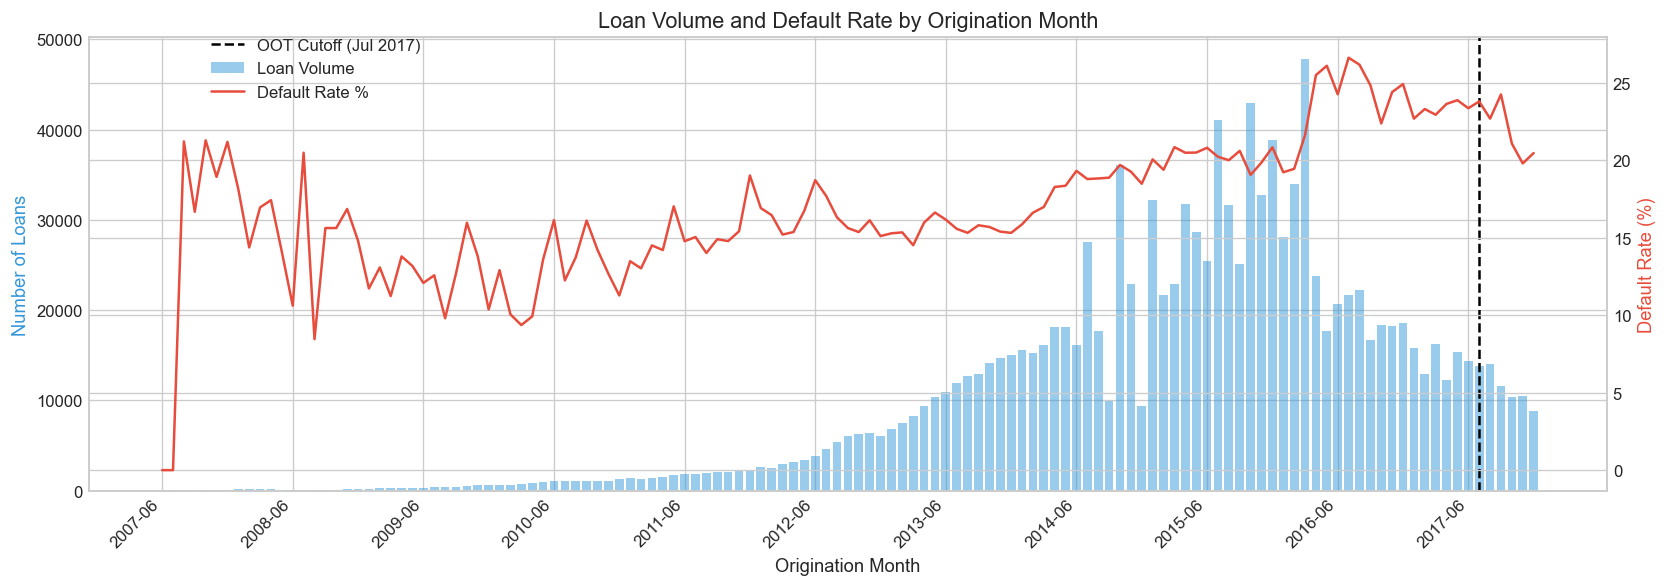

In [6]:
# Historical summary: loan volume and default rate by origination month
historical = (
    df.dropna(subset=["issue_date"])
    .groupby("issue_year_month")
    .agg(n_loans=(TARGET_COL, "size"), bad_rate=(TARGET_COL, "mean"))
    .reset_index()
)
historical["bad_rate_pct"] = (historical["bad_rate"] * 100).round(2)

fig, ax1 = plt.subplots(figsize=(14, 5))

# Loan volume as bars
x_labels = historical["issue_year_month"].astype(str)
ax1.bar(range(len(x_labels)), historical["n_loans"], color=COLORS["secondary"], alpha=0.5, label="Loan Volume")
ax1.set_ylabel("Number of Loans", color=COLORS["secondary"])
ax1.set_xlabel("Origination Month")

# Default rate as line on secondary axis
ax2 = ax1.twinx()
ax2.plot(range(len(x_labels)), historical["bad_rate_pct"], color=COLORS["default"], linewidth=1.5, label="Default Rate %")
ax2.set_ylabel("Default Rate (%)", color=COLORS["default"])

# Mark the cutoff
cutoff_label = "2017-07"
if cutoff_label in x_labels.values:
    cutoff_idx = list(x_labels.values).index(cutoff_label)
    ax1.axvline(x=cutoff_idx, color="black", linestyle="--", linewidth=1.5, label="OOT Cutoff (Jul 2017)")

# Format x-axis to show only every 12th label
tick_positions = list(range(0, len(x_labels), 12))
ax1.set_xticks(tick_positions)
ax1.set_xticklabels([x_labels.iloc[i] for i in tick_positions], rotation=45, ha="right")

ax1.set_title("Loan Volume and Default Rate by Origination Month")
fig.legend(loc="upper left", bbox_to_anchor=(0.12, 0.95))
plt.tight_layout()
plt.savefig(FIGURES_DIR / "oot_split_overview.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
# Step 1: Out-of-time split
OOT_CUTOFF = pd.Timestamp("2017-07-01")

mask_dev = df["issue_date"] < OOT_CUTOFF
mask_holdout = df["issue_date"] >= OOT_CUTOFF

df_dev = df.loc[mask_dev].copy()
df_holdout = df.loc[mask_holdout].copy()

print(f"Development set: {df_dev.shape[0]:,} loans ({df_dev.shape[0]/len(df):.1%}) | Default rate: {df_dev[TARGET_COL].mean():.2%}")
print(f"Holdout set:     {df_holdout.shape[0]:,} loans ({df_holdout.shape[0]/len(df):.1%}) | Default rate: {df_holdout[TARGET_COL].mean():.2%}")

print(f"\nDevelopment period: {df_dev['issue_date'].min().strftime('%Y-%m')} to {df_dev['issue_date'].max().strftime('%Y-%m')}")
print(f"Holdout period:     {df_holdout['issue_date'].min().strftime('%Y-%m')} to {df_holdout['issue_date'].max().strftime('%Y-%m')}")

# Step 2: Train / validation split within development sample
df_train, df_val = train_test_split(
    df_dev,
    test_size=0.2,
    stratify=df_dev[TARGET_COL],
    random_state=SEED,
)

print(f"\nTrain set:      {df_train.shape[0]:,} loans ({df_train.shape[0]/len(df_dev):.1%} of dev) | Default rate: {df_train[TARGET_COL].mean():.2%}")
print(f"Validation set: {df_val.shape[0]:,} loans ({df_val.shape[0]/len(df_dev):.1%} of dev) | Default rate: {df_val[TARGET_COL].mean():.2%}")

Development set: 1,200,975 loans (94.5%) | Default rate: 19.93%
Holdout set:     69,339 loans (5.5%) | Default rate: 22.20%

Development period: 2007-06 to 2017-06
Holdout period:     2017-07 to 2017-12

Train set:      960,780 loans (80.0% of dev) | Default rate: 19.93%
Validation set: 240,195 loans (20.0% of dev) | Default rate: 19.93%


> **Note on the split design:**  
> All 2018 loans are excluded because they do not yet have sufficient performance history for default outcomes to be fully observed. The development sample spans 2007–June 2017, while the out-of-time holdout covers July–December 2017, giving a compact 6-month forward test window.

> The development sample is then split into **training** and **validation** subsets.  
> **All EDA below is conducted exclusively on `df_train`**. Both `df_val` and `df_holdout` remain untouched by target-conditioned exploration.

## 1.3 Target Distribution in Training Set

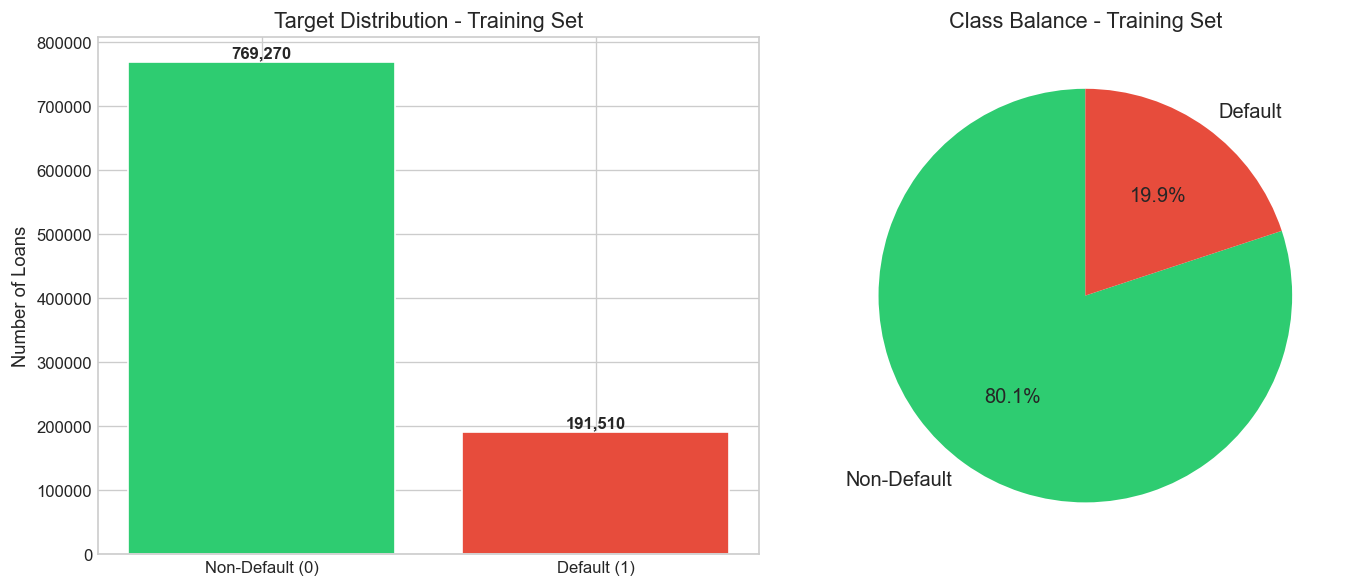

Training set default rate: 19.93%
Imbalance ratio: 4.0 : 1 (non-default : default)


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts = df_train[TARGET_COL].value_counts().sort_index()
colors = [COLORS["non_default"], COLORS["default"]]

# Bar chart
bars = axes[0].bar(["Non-Default (0)", "Default (1)"], counts.values, color=colors, edgecolor="white")
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2000,
                 f"{val:,}", ha="center", va="bottom", fontweight="bold")
axes[0].set_title("Target Distribution - Training Set")
axes[0].set_ylabel("Number of Loans")

# Pie chart
axes[1].pie(counts.values, labels=["Non-Default", "Default"], colors=colors,
            autopct="%1.1f%%", startangle=90, textprops={"fontsize": 12})
axes[1].set_title("Class Balance - Training Set")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "target_distribution_train.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Training set default rate: {df_train[TARGET_COL].mean():.2%}")
print(f"Imbalance ratio: {counts[0] / counts[1]:.1f} : 1 (non-default : default)")

> **Business context:** The training set has approximately a 20% default rate, reflecting a 4:1 class imbalance. This is a moderately imbalanced classification problem - not extreme enough to require aggressive resampling, but sufficient to warrant careful metric selection(ROC-AUC, precision-recall) over simple accuracy.

## 2. Default Rate Analysis Across Key Features

This section examines how the default rate varies across the most important borrower and loan characteristics. The goal is to identify **risk signals** that a credit screening model should capture, and to surface any non-linear relationships or interaction effects.

We focus on features that are **available at loan origination** and that a lending officer or
automated underwriting system would use to make approval decisions.

### 2.1 Loan Grade / Sub-Grade

LendingClub assigns a sub-grade (A1-G5) (grade (A-G) was previously dropped in Notebook 1) to each loan based on its internal credit model. These grades directly determine the interest rate offered. If the grading system is well-calibrated, we expect a monotonically increasing default rate from A1 to G5.

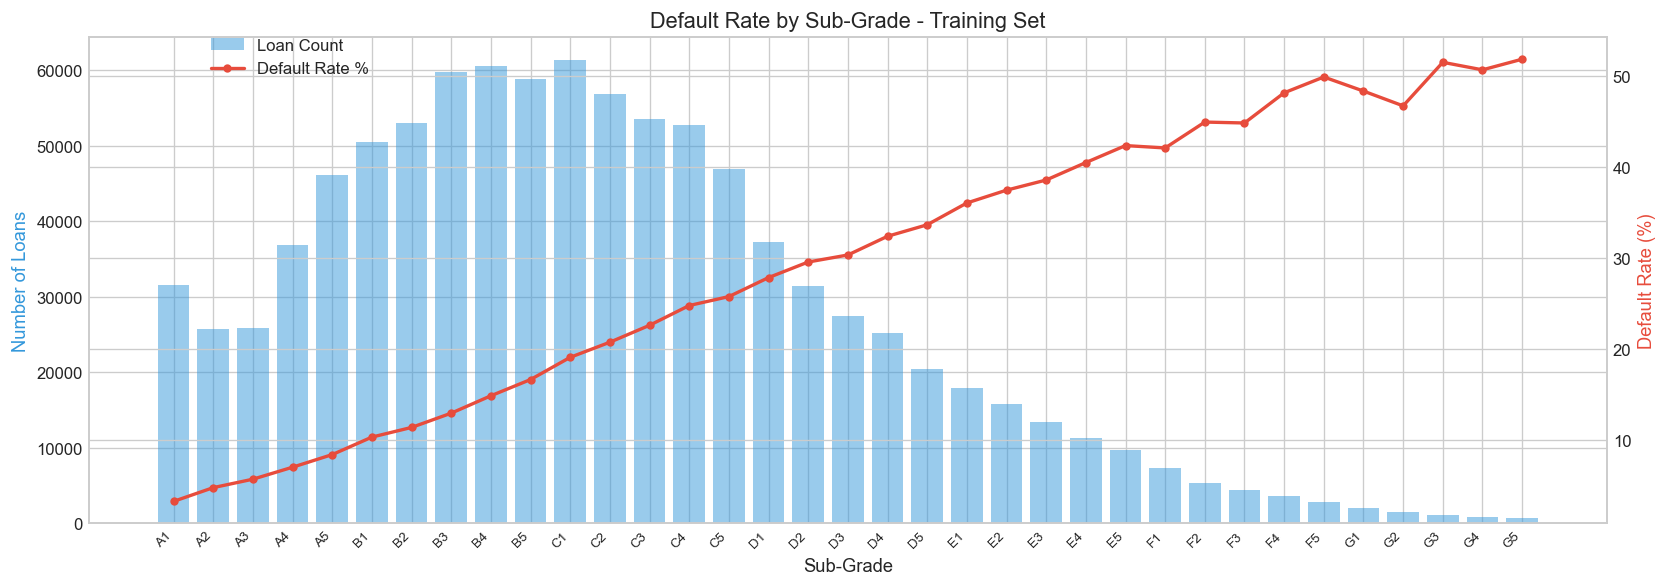

In [9]:
# Default rate by sub-grade
subgrade_stats = (
    df_train.groupby("sub_grade")[TARGET_COL]
    .agg(["count", "mean"])
    .rename(columns={"count": "n_loans", "mean": "default_rate"})
    .reset_index()
    .sort_values("sub_grade")
)

fig, ax1 = plt.subplots(figsize=(14, 5))

# Bar: loan count
ax1.bar(range(len(subgrade_stats)), subgrade_stats["n_loans"],
        color=COLORS["secondary"], alpha=0.5, label="Loan Count")
ax1.set_ylabel("Number of Loans", color=COLORS["secondary"])
ax1.set_xlabel("Sub-Grade")

# Line: default rate
ax2 = ax1.twinx()
ax2.plot(range(len(subgrade_stats)), subgrade_stats["default_rate"] * 100,
         color=COLORS["default"], linewidth=2, marker="o", markersize=4, label="Default Rate %")
ax2.set_ylabel("Default Rate (%)", color=COLORS["default"])

ax1.set_xticks(range(len(subgrade_stats)))
ax1.set_xticklabels(subgrade_stats["sub_grade"], rotation=45, ha="right", fontsize=8)
ax1.set_title("Default Rate by Sub-Grade - Training Set")
fig.legend(loc="upper left", bbox_to_anchor=(0.12, 0.95))
plt.tight_layout()
plt.savefig(FIGURES_DIR / "default_rate_by_subgrade.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
# Summary table for grade-level default rates
df_train["grade_letter"] = df_train["sub_grade"].str[0]
grade_summary = (
    df_train.groupby("grade_letter")[TARGET_COL]
    .agg(["count", "mean"])
    .rename(columns={"count": "n_loans", "mean": "default_rate"})
    .reset_index()
)
grade_summary["default_rate_pct"] = (grade_summary["default_rate"] * 100).round(2)
grade_summary

,grade_letter,n_loans,default_rate,default_rate_pct
0,A,166272,0.060762,6.08
1,B,282971,0.133197,13.32
2,C,271544,0.223548,22.35
3,D,141933,0.303291,30.33
4,E,68278,0.384926,38.49
5,F,23630,0.451037,45.10
6,G,6152,0.491873,49.19


In [11]:
subgrade_summary = (
    df_train.groupby("sub_grade")[TARGET_COL]
    .agg(["count", "mean"])
    .rename(columns={"count": "n_loans", "mean": "default_rate"})
    .reset_index()
)
subgrade_summary["default_rate_pct"] = (subgrade_summary["default_rate"] * 100).round(2)
subgrade_summary

,sub_grade,n_loans,default_rate,default_rate_pct
0,A1,31544,0.031987,3.20
1,A2,25754,0.047099,4.71
2,A3,25930,0.056383,5.64
3,A4,36891,0.069583,6.96
4,A5,46153,0.083462,8.35
5,B1,50555,0.102700,10.27
6,B2,53095,0.113344,11.33
7,B3,59754,0.129046,12.90
8,B4,60635,0.148182,14.82
9,B5,58932,0.166039,16.60


> **Insight:** The default rate increases monotonically from Grade A (≈6%) to Grade G (≈50%+),confirming that LendingClub's internal grading system captures meaningful credit risk. Sub-grade provides finer granularity and will be a strong candidate predictor.  
> However, since `sub_grade` effectively encodes the platform's own risk model, we should be mindful that it may dominate other features - in practice, a lender might want to know what drives risk **beyond** the assigned grade.

### 2.2 Interest Rate

Interest rate is set by LendingClub based on the borrower's risk profile. Higher rates compensate investors for higher expected default risk.

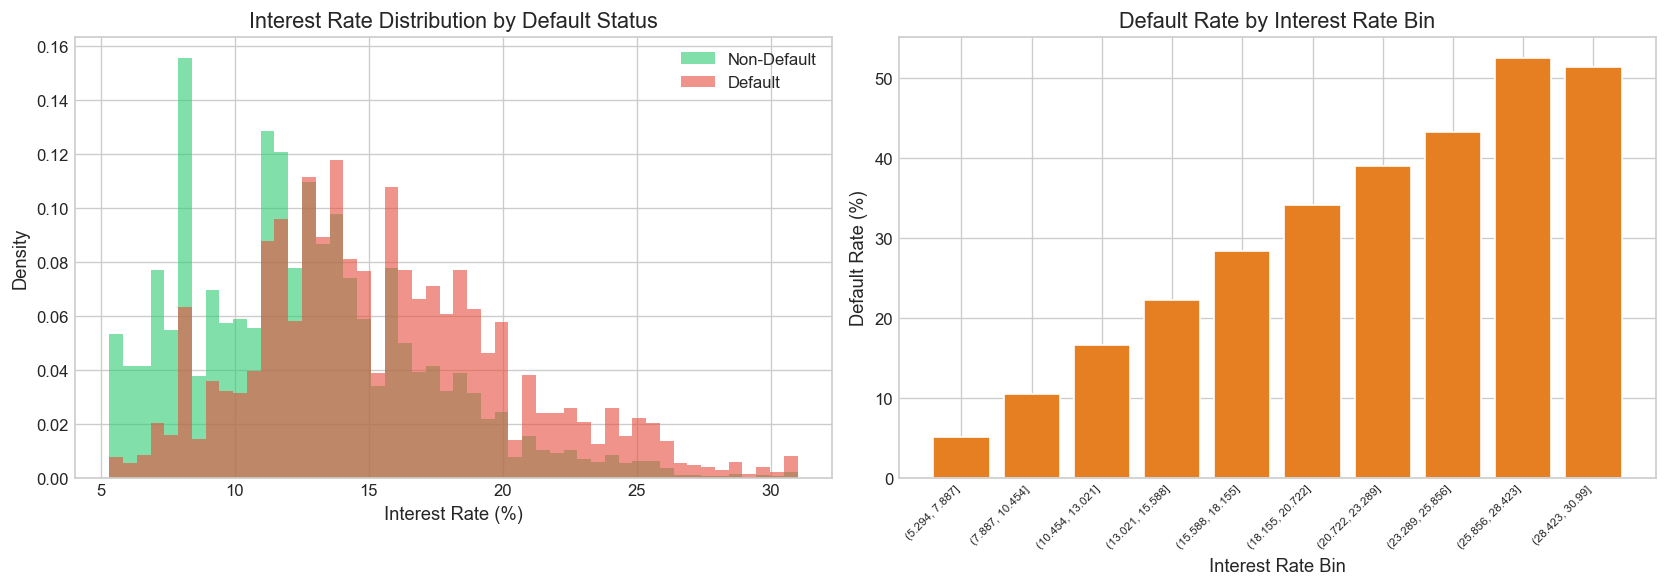

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution by target
for label, color, name in [(0, COLORS["non_default"], "Non-Default"),
                            (1, COLORS["default"], "Default")]:
    subset = df_train.loc[df_train[TARGET_COL] == label, "int_rate"].dropna()
    axes[0].hist(subset, bins=50, alpha=0.6, color=color, label=name, density=True)
axes[0].set_title("Interest Rate Distribution by Default Status")
axes[0].set_xlabel("Interest Rate (%)")
axes[0].set_ylabel("Density")
axes[0].legend()

# Default rate by interest rate bin
df_train["int_rate_bin"] = pd.cut(df_train["int_rate"], bins=10)
rate_by_bin = (
    df_train.groupby("int_rate_bin", observed=True)[TARGET_COL]
    .agg(["count", "mean"])
    .reset_index()
)
axes[1].bar(range(len(rate_by_bin)), rate_by_bin["mean"] * 100, color=COLORS["accent"], edgecolor="white")
axes[1].set_xticks(range(len(rate_by_bin)))
axes[1].set_xticklabels([str(x) for x in rate_by_bin["int_rate_bin"]], rotation=45, ha="right", fontsize=7)
axes[1].set_title("Default Rate by Interest Rate Bin")
axes[1].set_ylabel("Default Rate (%)")
axes[1].set_xlabel("Interest Rate Bin")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "interest_rate_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

df_train.drop(columns=["int_rate_bin"], inplace=True)

> **Insight:** Defaulted loans have a clearly higher average interest rate, and the default rate increases steeply with the interest rate bin. This is expected - LendingClub charges higher rates to riskier borrowers. Interest rate is highly correlated with sub-grade and will need careful handling to avoid multicollinearity in linear models.

### 2.3 Loan Term

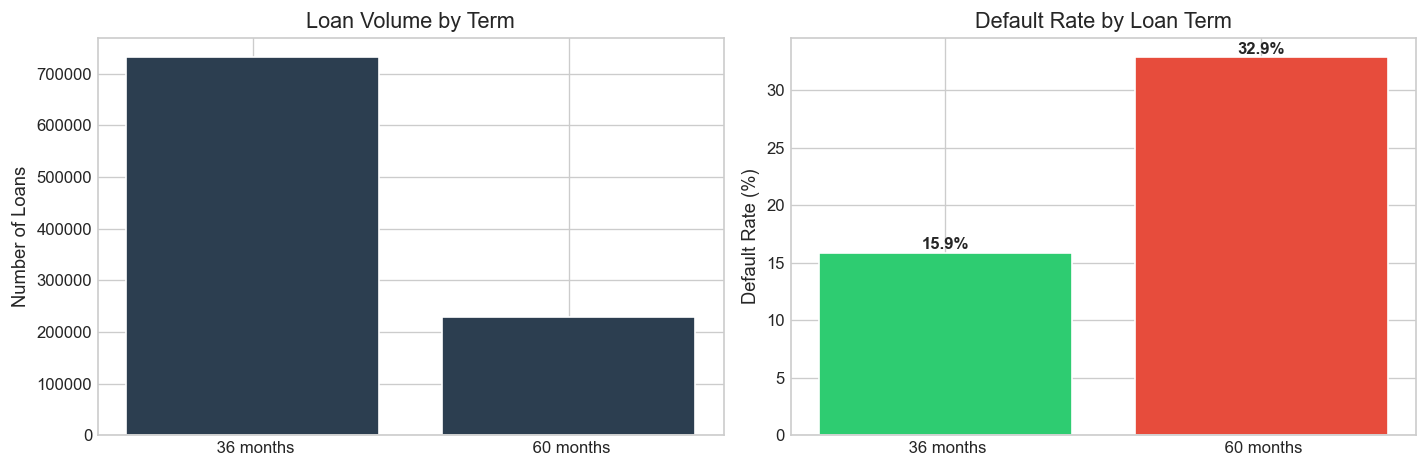

,term,n_loans,default_rate,default_rate_pct
0,36 months,732218,0.158842,15.88
1,60 months,228562,0.329027,32.90


In [13]:
term_stats = (
    df_train.groupby("term")[TARGET_COL]
    .agg(["count", "mean"])
    .rename(columns={"count": "n_loans", "mean": "default_rate"})
    .reset_index()
)
term_stats["default_rate_pct"] = (term_stats["default_rate"] * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Volume
axes[0].bar(term_stats["term"], term_stats["n_loans"], color=COLORS["primary"], edgecolor="white")
axes[0].set_title("Loan Volume by Term")
axes[0].set_ylabel("Number of Loans")

# Default rate
bars = axes[1].bar(term_stats["term"], term_stats["default_rate_pct"],
                   color=[COLORS["non_default"], COLORS["default"]], edgecolor="white")
for bar, val in zip(bars, term_stats["default_rate_pct"]):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 f"{val:.1f}%", ha="center", fontweight="bold")
axes[1].set_title("Default Rate by Loan Term")
axes[1].set_ylabel("Default Rate (%)")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "term_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

term_stats

> **Insight:** 60-month loans have a substantially higher default rate than 36-month loans  
> This makes business sense: longer-term loans expose the lender to more economic uncertainty, and borrowers who choose longer terms may be stretching their repayment capacity.

### 2.4 FICO Score at Origination

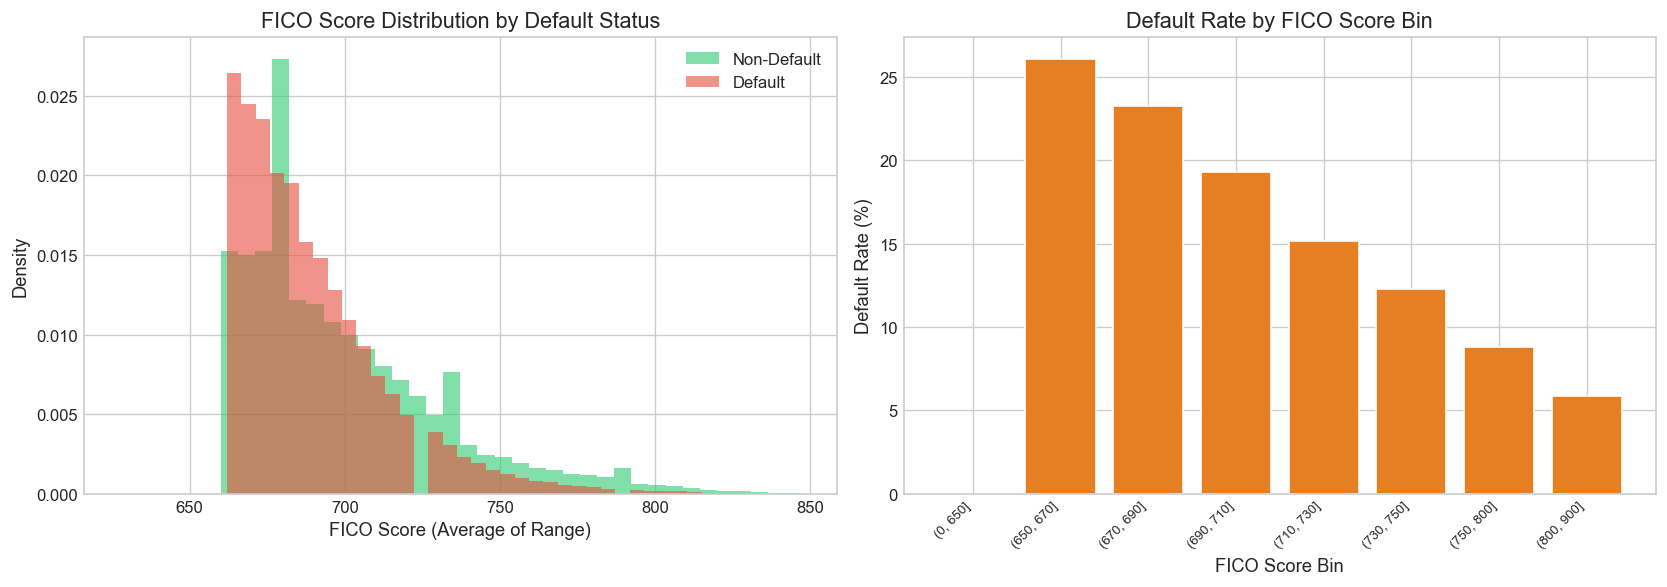

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution by target
for label, color, name in [(0, COLORS["non_default"], "Non-Default"),
                            (1, COLORS["default"], "Default")]:
    subset = df_train.loc[df_train[TARGET_COL] == label, "fico_avg"].dropna()
    axes[0].hist(subset, bins=40, alpha=0.6, color=color, label=name, density=True)
axes[0].set_title("FICO Score Distribution by Default Status")
axes[0].set_xlabel("FICO Score (Average of Range)")
axes[0].set_ylabel("Density")
axes[0].legend()

# Default rate by FICO bin
df_train["fico_bin"] = pd.cut(df_train["fico_avg"], bins=[0, 650, 670, 690, 710, 730, 750, 800, 900])
fico_by_bin = (
    df_train.groupby("fico_bin", observed=True)[TARGET_COL]
    .agg(["count", "mean"])
    .reset_index()
)
axes[1].bar(range(len(fico_by_bin)), fico_by_bin["mean"] * 100, color=COLORS["accent"], edgecolor="white")
axes[1].set_xticks(range(len(fico_by_bin)))
axes[1].set_xticklabels([str(x) for x in fico_by_bin["fico_bin"]], rotation=45, ha="right", fontsize=8)
axes[1].set_title("Default Rate by FICO Score Bin")
axes[1].set_ylabel("Default Rate (%)")
axes[1].set_xlabel("FICO Score Bin")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fico_score_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

df_train.drop(columns=["fico_bin"], inplace=True)

> **Insight:** There is a clear inverse relationship between FICO score and default rate  
> Borrowers with FICO scores below 670 have default rates **exceeding 25%**, while those above 750 default at **less than 10%**. FICO score is one of the strongest univariate predictors of default - this is consistent with its role as the industry-standard credit risk measure

### 2.5 Annual Income and Debt-to-Income Ratio

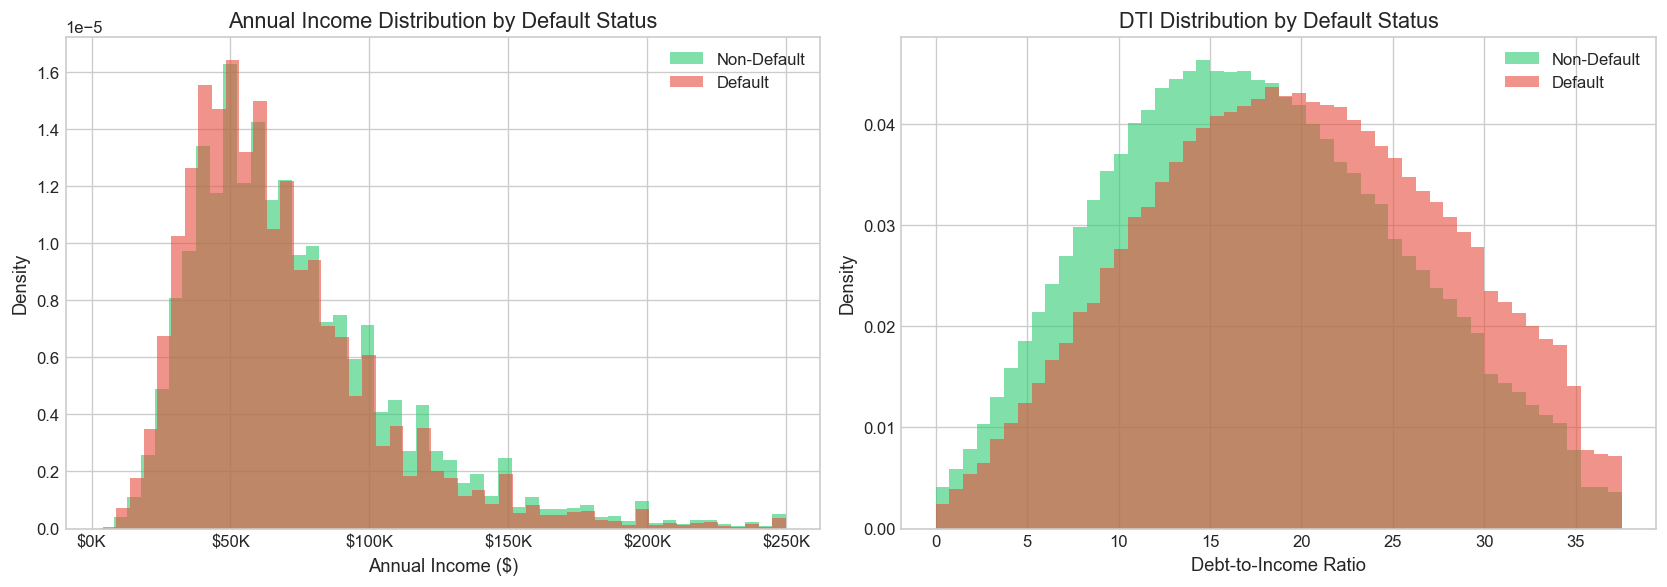

,dti_bin,n_loans,default_rate,default_rate_pct
0,"(0, 10]",172565,0.145383,14.54
1,"(10, 15]",196533,0.165764,16.58
2,"(15, 20]",208601,0.190675,19.07
3,"(20, 25]",174807,0.218778,21.88
4,"(25, 30]",120480,0.249270,24.93
5,"(30, 40]",85849,0.293341,29.33
6,"(40, 100]",1505,0.357475,35.75


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Annual income (capped at 99th percentile for visualization)
inc_cap = df_train["annual_inc"].quantile(0.99)
for label, color, name in [(0, COLORS["non_default"], "Non-Default"),
                            (1, COLORS["default"], "Default")]:
    subset = df_train.loc[(df_train[TARGET_COL] == label) & (df_train["annual_inc"] <= inc_cap), "annual_inc"]
    axes[0].hist(subset, bins=50, alpha=0.6, color=color, label=name, density=True)
axes[0].set_title("Annual Income Distribution by Default Status")
axes[0].set_xlabel("Annual Income ($)")
axes[0].set_ylabel("Density")
axes[0].legend()
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x/1000:.0f}K"))

# DTI
dti_cap = df_train["dti"].quantile(0.99)
for label, color, name in [(0, COLORS["non_default"], "Non-Default"),
                            (1, COLORS["default"], "Default")]:
    subset = df_train.loc[(df_train[TARGET_COL] == label) & (df_train["dti"] <= dti_cap) & (df_train["dti"] >= 0), "dti"]
    axes[1].hist(subset, bins=50, alpha=0.6, color=color, label=name, density=True)
axes[1].set_title("DTI Distribution by Default Status")
axes[1].set_xlabel("Debt-to-Income Ratio")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "income_dti_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

# Default rate by DTI bin
df_train["dti_bin"] = pd.cut(df_train["dti"].clip(lower=0), bins=[0, 10, 15, 20, 25, 30, 40, 100])
dti_stats = (
    df_train.groupby("dti_bin", observed=True)[TARGET_COL]
    .agg(["count", "mean"])
    .rename(columns={"count": "n_loans", "mean": "default_rate"})
    .reset_index()
)
dti_stats["default_rate_pct"] = (dti_stats["default_rate"] * 100).round(2)
dti_stats

In [16]:
df_train.drop(columns=["dti_bin"], inplace=True)

> **Insight:** Borrowers with higher DTI ratios default more frequently, as expected - a higher debt burden relative to income leaves less capacity to absorb financial shocks
> Annual income shows a weaker but still meaningful relationship: lower-income borrowers default at slightly higher rates. However, income alone is less discriminating than DTI because LendingClub already adjusts loan amounts and rates based on income.

### 2.6 Home Ownership

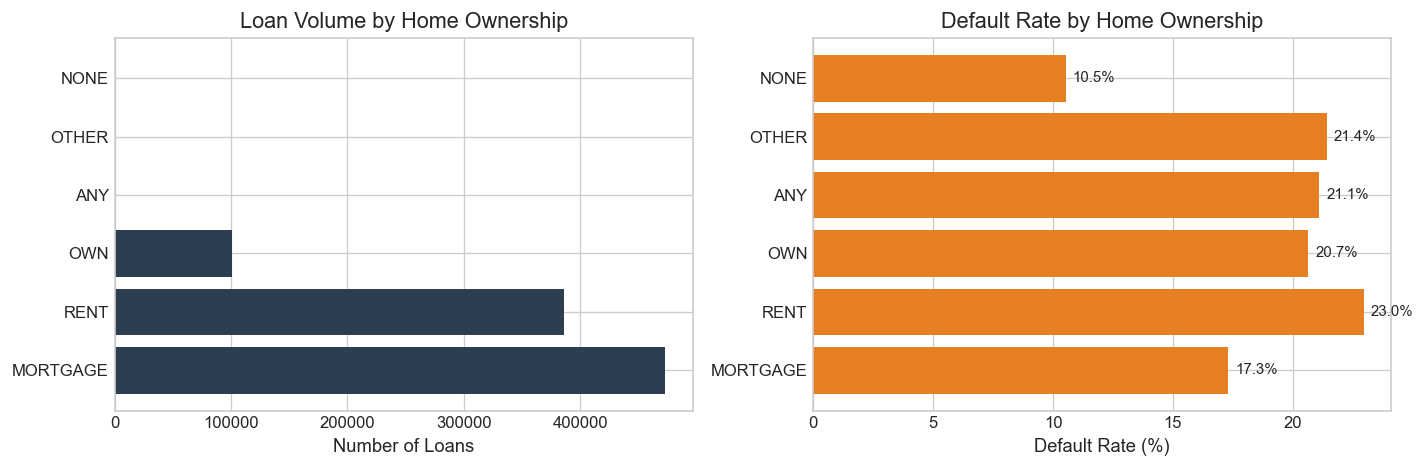

,home_ownership,n_loans,default_rate,default_rate_pct
5,RENT,386100,0.229731,22.97
3,OTHER,112,0.214286,21.43
0,ANY,199,0.211055,21.11
4,OWN,101299,0.206596,20.66
1,MORTGAGE,473032,0.172954,17.30
2,NONE,38,0.105263,10.53


In [17]:
home_stats = (
    df_train.groupby("home_ownership")[TARGET_COL]
    .agg(["count", "mean"])
    .rename(columns={"count": "n_loans", "mean": "default_rate"})
    .reset_index()
    .sort_values("n_loans", ascending=False)
)
home_stats["default_rate_pct"] = (home_stats["default_rate"] * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].barh(home_stats["home_ownership"], home_stats["n_loans"], color=COLORS["primary"])
axes[0].set_title("Loan Volume by Home Ownership")
axes[0].set_xlabel("Number of Loans")

axes[1].barh(home_stats["home_ownership"], home_stats["default_rate_pct"], color=COLORS["accent"])
for i, (val, n) in enumerate(zip(home_stats["default_rate_pct"], home_stats["n_loans"])):
    axes[1].text(val + 0.3, i, f"{val:.1f}%", va="center", fontsize=9)
axes[1].set_title("Default Rate by Home Ownership")
axes[1].set_xlabel("Default Rate (%)")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "home_ownership_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

home_stats.sort_values(by = ['default_rate_pct'], ascending = False)

> **Insight:** Default rates are highest among renters (≈23%), followed by homeowners who own outright (≈20.6%), while mortgage holders exhibit the lowest default rate (≈17.3%) among the major groups. This suggests that borrowers with active mortgages may be more financially stable or better screened.

> The categories `ANY`, `NONE`, and `OTHER` have very few observations and show unstable default rates, so they should be grouped into an "Other" category during preprocessing to avoid noise.

### 2.7 Loan Purpose

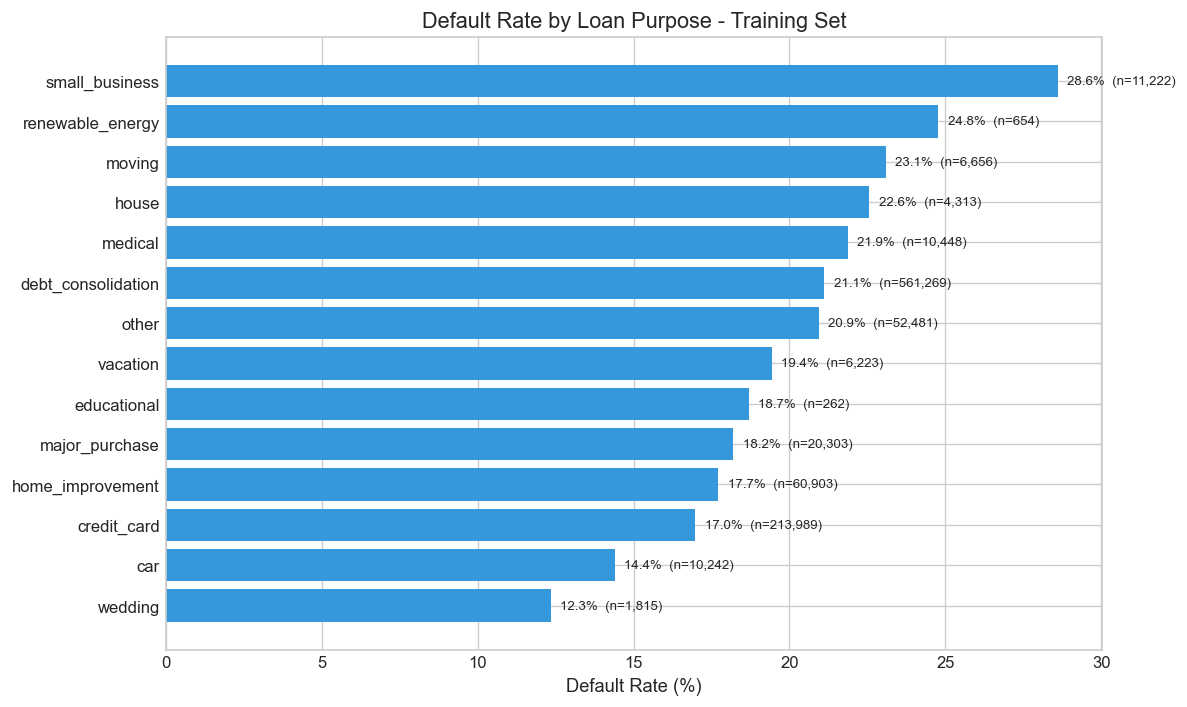

In [18]:
purpose_stats = (
    df_train.groupby("purpose")[TARGET_COL]
    .agg(["count", "mean"])
    .rename(columns={"count": "n_loans", "mean": "default_rate"})
    .reset_index()
    .sort_values("default_rate", ascending=False)
)
purpose_stats["default_rate_pct"] = (purpose_stats["default_rate"] * 100).round(2)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(purpose_stats["purpose"], purpose_stats["default_rate_pct"], color=COLORS["secondary"])
for i, (val, n) in enumerate(zip(purpose_stats["default_rate_pct"], purpose_stats["n_loans"])):
    ax.text(val + 0.3, i, f"{val:.1f}%  (n={n:,})", va="center", fontsize=8)
ax.set_title("Default Rate by Loan Purpose - Training Set")
ax.set_xlabel("Default Rate (%)")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "purpose_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

> **Insight:** Small business loans have the highest default rate (≈29%), consistent with the inherently higher risk of business ventures  
> Debt consolidation - the most common purpose - has a moderate default rate (≈21%)  
> Car, Credit card refinancing and wedding loans tend to have lower default rates. Loan purpose provides meaningful risk segmentation.

### 2.8 Employment Length

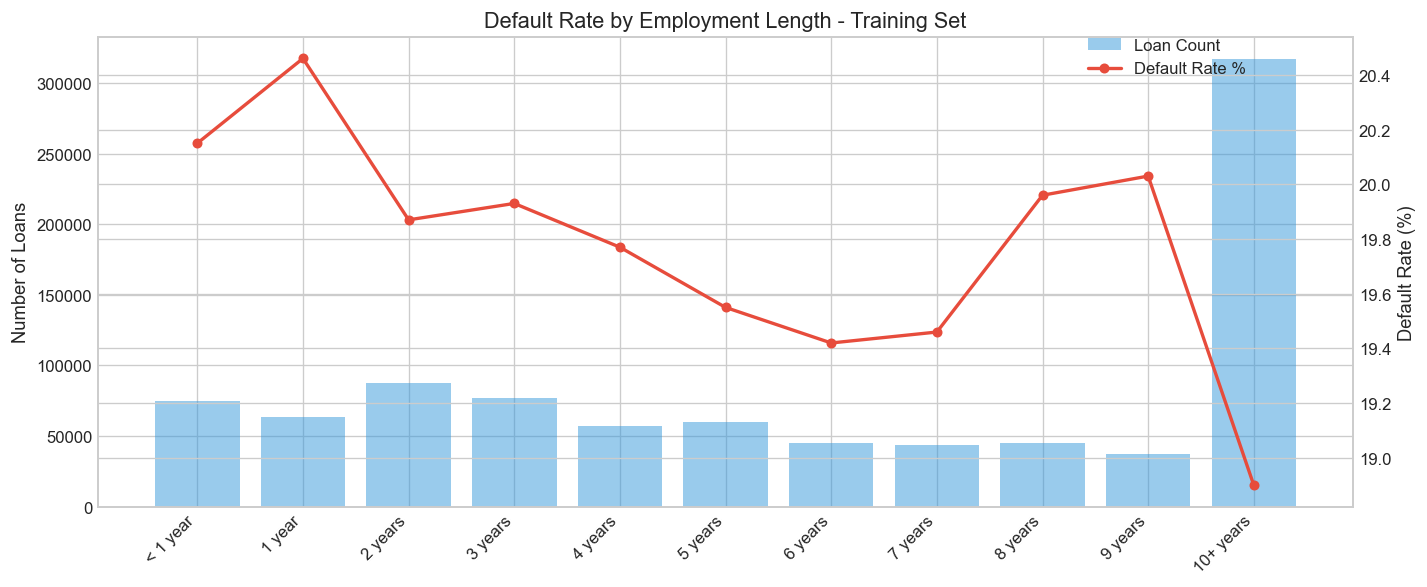

In [19]:
# Define a logical ordering for employment length
emp_order = ["< 1 year", "1 year", "2 years", "3 years", "4 years", "5 years",
             "6 years", "7 years", "8 years", "9 years", "10+ years"]

emp_stats = (
    df_train.groupby("emp_length")[TARGET_COL]
    .agg(["count", "mean"])
    .rename(columns={"count": "n_loans", "mean": "default_rate"})
    .reset_index()
)
# Reorder
emp_stats["emp_length"] = pd.Categorical(emp_stats["emp_length"], categories=emp_order, ordered=True)
emp_stats = emp_stats.sort_values("emp_length").dropna(subset=["emp_length"])
emp_stats["default_rate_pct"] = (emp_stats["default_rate"] * 100).round(2)

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.bar(range(len(emp_stats)), emp_stats["n_loans"], color=COLORS["secondary"], alpha=0.5, label="Loan Count")
ax1.set_ylabel("Number of Loans")

ax2 = ax1.twinx()
ax2.plot(range(len(emp_stats)), emp_stats["default_rate_pct"], color=COLORS["default"],
         linewidth=2, marker="o", markersize=5, label="Default Rate %")
ax2.set_ylabel("Default Rate (%)")

ax1.set_xticks(range(len(emp_stats)))
ax1.set_xticklabels(emp_stats["emp_length"], rotation=45, ha="right")
ax1.set_title("Default Rate by Employment Length - Training Set")
fig.legend(loc="upper right", bbox_to_anchor=(0.88, 0.95))
plt.tight_layout()
plt.savefig(FIGURES_DIR / "emp_length_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

In [20]:
df_train['emp_length'].isna().sum()/df_train.shape[0]

np.float64(0.055371677178958766)

> **Insight:** Employment length shows a relatively flat default rate across categories, with only a slight decrease for borrowers with 10+ years of employment. This suggests that employment length alone is a weak predictor of default - LendingClub's grading system may already account for employment stability. The missing values in `emp_length`(≈5%) should be treated as a separate category rather than imputed.

### 2.9 Verification Status

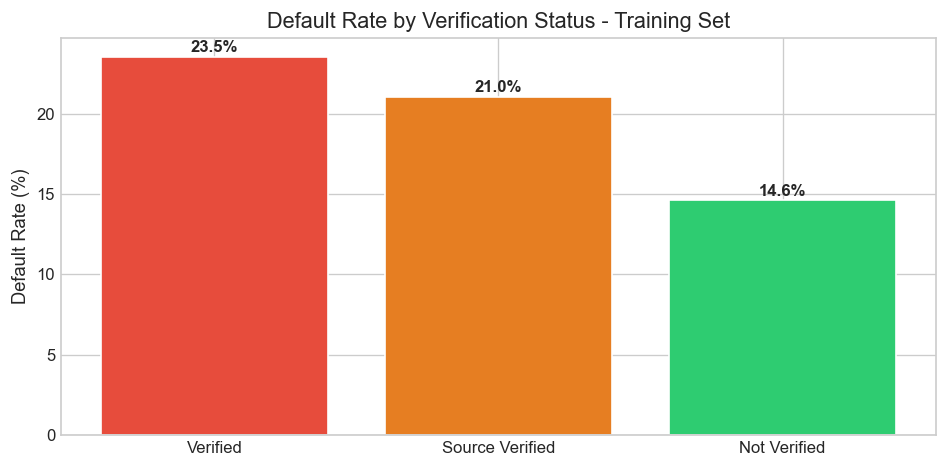

,verification_status,n_loans,default_rate,default_rate_pct
2,Verified,304537,0.235252,23.53
1,Source Verified,373219,0.210394,21.04
0,Not Verified,283024,0.146079,14.61


In [21]:
verif_stats = (
    df_train.groupby("verification_status")[TARGET_COL]
    .agg(["count", "mean"])
    .rename(columns={"count": "n_loans", "mean": "default_rate"})
    .reset_index()
    .sort_values("default_rate", ascending=False)
)
verif_stats["default_rate_pct"] = (verif_stats["default_rate"] * 100).round(2)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(verif_stats["verification_status"], verif_stats["default_rate_pct"],
              color=[COLORS["default"], COLORS["accent"], COLORS["non_default"]], edgecolor="white")
for bar, val in zip(bars, verif_stats["default_rate_pct"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f"{val:.1f}%", ha="center", fontweight="bold")
ax.set_title("Default Rate by Verification Status - Training Set")
ax.set_ylabel("Default Rate (%)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "verification_status_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

verif_stats

> **Insight:** Counter-intuitively, verified and source-verified borrowers have **higher** default rates than non-verified borrowers. This is a well-known pattern in the LendingClub data: verification is triggered for borrowers who appear riskier, so it acts as a proxy for risk rather than a mitigant. This is an important feature to retain.

### 2.10 Revolving Utilization and Credit Behaviour

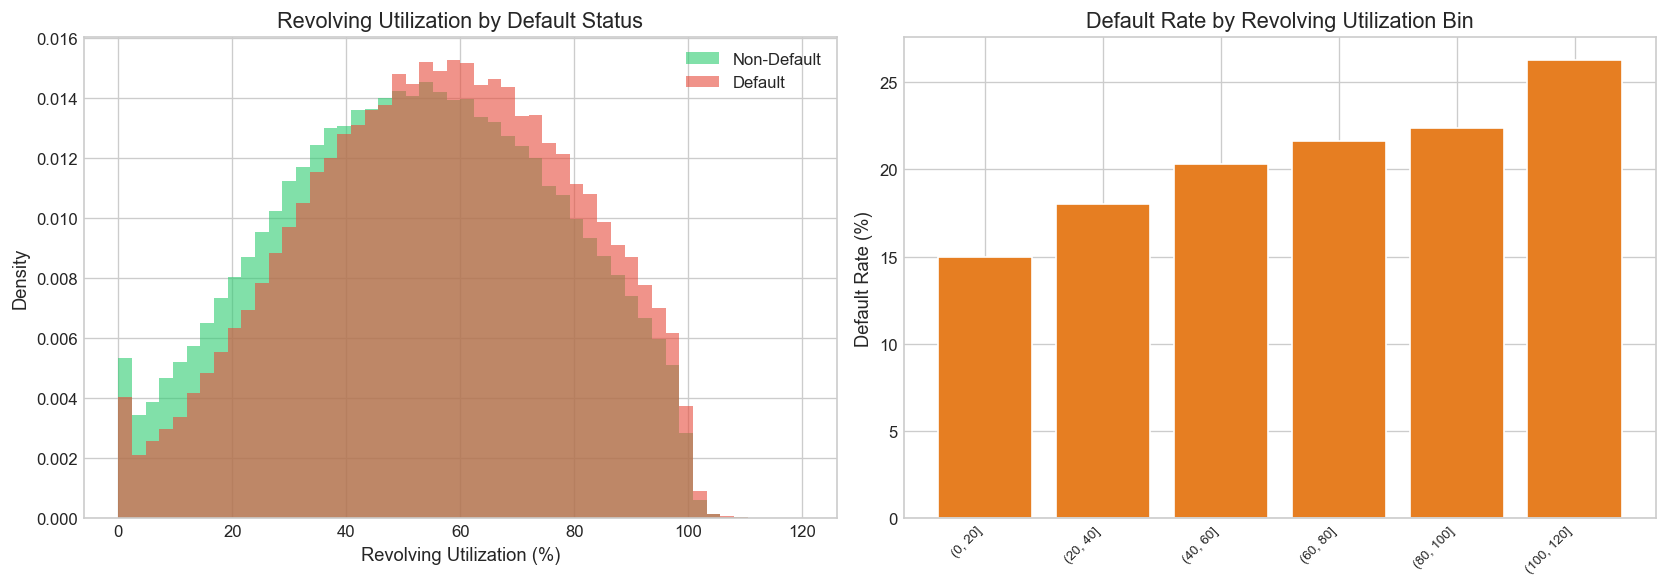

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Revolving utilization
revol_cap = 120  # cap for visualization
for label, color, name in [(0, COLORS["non_default"], "Non-Default"),
                            (1, COLORS["default"], "Default")]:
    subset = df_train.loc[(df_train[TARGET_COL] == label) & (df_train["revol_util"] <= revol_cap), "revol_util"].dropna()
    axes[0].hist(subset, bins=50, alpha=0.6, color=color, label=name, density=True)
axes[0].set_title("Revolving Utilization by Default Status")
axes[0].set_xlabel("Revolving Utilization (%)")
axes[0].set_ylabel("Density")
axes[0].legend()

# Default rate by revol_util bin
df_train["revol_util_bin"] = pd.cut(df_train["revol_util"].clip(upper=120), bins=[0, 20, 40, 60, 80, 100, 120])
revol_by_bin = (
    df_train.groupby("revol_util_bin", observed=True)[TARGET_COL]
    .agg(["count", "mean"])
    .reset_index()
)
axes[1].bar(range(len(revol_by_bin)), revol_by_bin["mean"] * 100, color=COLORS["accent"], edgecolor="white")
axes[1].set_xticks(range(len(revol_by_bin)))
axes[1].set_xticklabels([str(x) for x in revol_by_bin["revol_util_bin"]], rotation=45, ha="right", fontsize=8)
axes[1].set_title("Default Rate by Revolving Utilization Bin")
axes[1].set_ylabel("Default Rate (%)")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "revol_util_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

df_train.drop(columns=["revol_util_bin"], inplace=True)

> **Insight:** Higher revolving utilization is strongly associated with higher default rates -  could imply that high utilization indicates financial stress and limited credit headroom

### 2.11 Inquiries in Last 6 Months

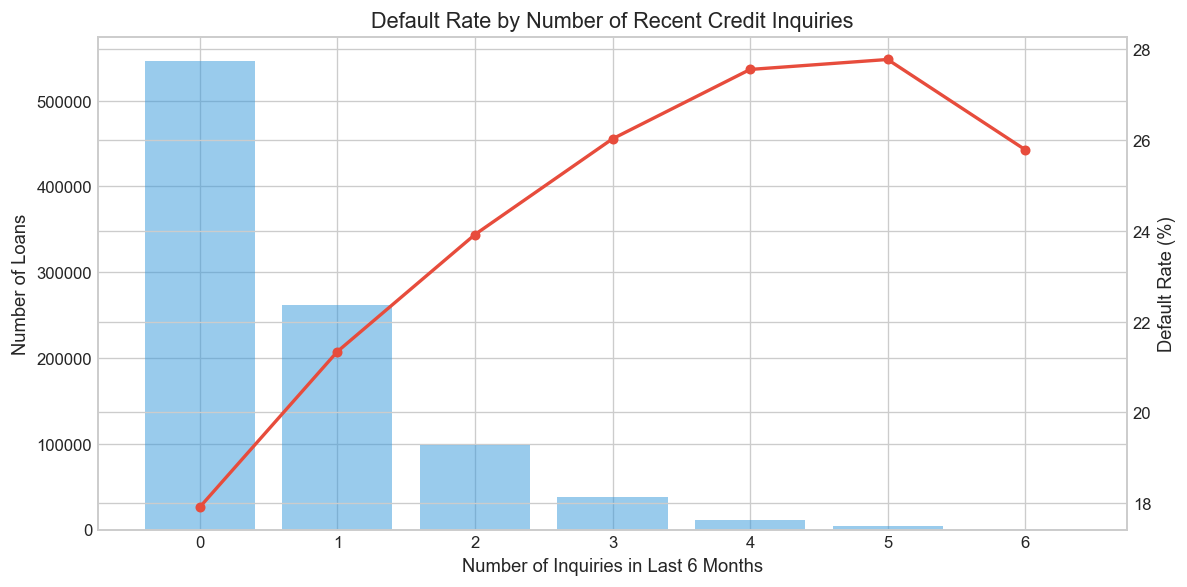

In [23]:
inq_stats = (
    df_train.groupby("inq_last_6mths")[TARGET_COL]
    .agg(["count", "mean"])
    .rename(columns={"count": "n_loans", "mean": "default_rate"})
    .reset_index()
)
inq_stats = inq_stats[inq_stats["n_loans"] >= 100]  # filter small groups
inq_stats["default_rate_pct"] = (inq_stats["default_rate"] * 100).round(2)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(inq_stats["inq_last_6mths"], inq_stats["n_loans"], color=COLORS["secondary"], alpha=0.5)
ax1.set_ylabel("Number of Loans")
ax1.set_xlabel("Number of Inquiries in Last 6 Months")

ax2 = ax1.twinx()
ax2.plot(inq_stats["inq_last_6mths"], inq_stats["default_rate_pct"],
         color=COLORS["default"], linewidth=2, marker="o", markersize=5)
ax2.set_ylabel("Default Rate (%)")
ax1.set_title("Default Rate by Number of Recent Credit Inquiries")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "inquiries_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

> **Insight:** More credit inquiries in the past 6 months correlate with higher default rates. This is consistent with the "credit-hungry" borrower hypothesis - frequent applications for new credit may signal financial distress or over-leveraging.

## 3. Correlation Analysis

### 3.1 Correlation with the Target Variable

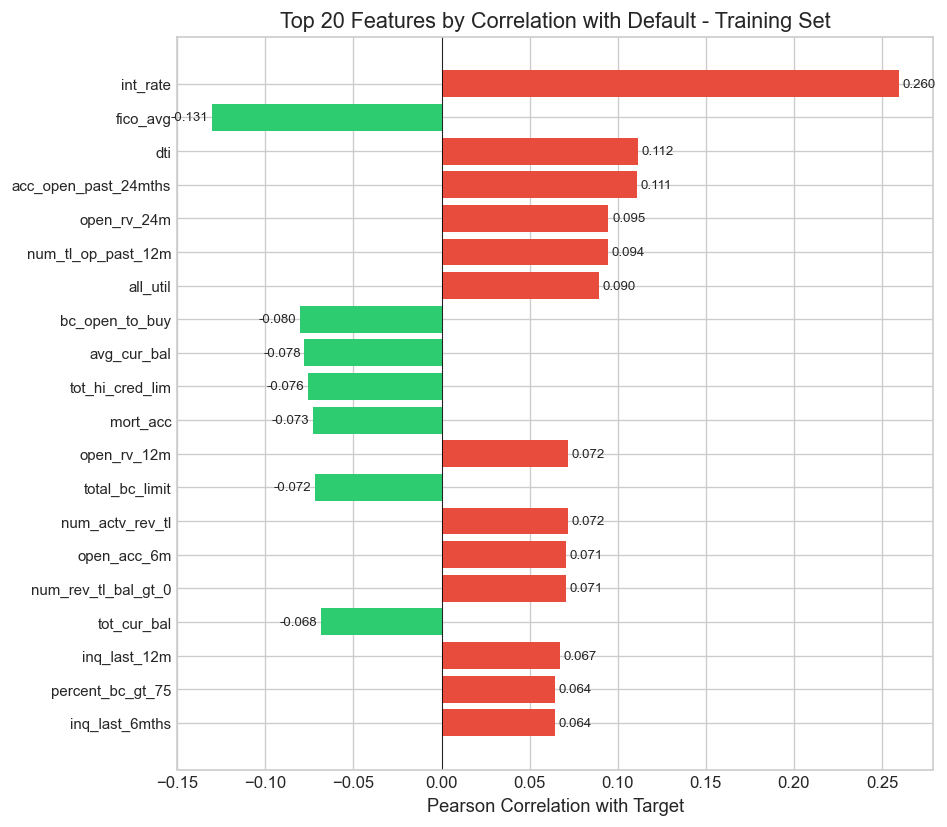

In [24]:
# Select numeric features for correlation analysis
# Exclude target and date-derived columns to avoid leakage or non-informative signals
exclude_from_corr = [TARGET_COL, "issue_year", "issue_month", "grade_letter"]

# Get all numeric columns, then filter out excluded ones
numeric_features = [
    c for c in df_train.select_dtypes(include=[np.number]).columns
    if c not in exclude_from_corr
]

# Compute Pearson correlation of each numeric feature with the target
target_corr = (
    df_train[numeric_features + [TARGET_COL]]  # subset relevant columns
    .corr()[TARGET_COL]                        # get correlation with target
    .drop(TARGET_COL)                          # remove self-correlation (=1)
    .sort_values(key=abs, ascending=False)     # sort by absolute strength
)

# Select top 20 features with strongest correlation (positive or negative)
top_corr = target_corr.head(20)

# Initialize plot
fig, ax = plt.subplots(figsize=(8, 7))

# Color bars based on direction of correlation
# Positive → default color, Negative → non-default color
colors_corr = [
    COLORS["default"] if v > 0 else COLORS["non_default"]
    for v in top_corr.values
]

# Create horizontal bar chart
ax.barh(range(len(top_corr)), top_corr.values, color=colors_corr)

# Set feature names as y-axis labels
ax.set_yticks(range(len(top_corr)))
ax.set_yticklabels(top_corr.index, fontsize=9)

# Axis labels and title
ax.set_xlabel("Pearson Correlation with Target")
ax.set_title("Top 20 Features by Correlation with Default - Training Set")

# Show strongest feature at the top
ax.invert_yaxis()

# Add vertical line at zero to separate positive vs negative correlations
ax.axvline(x=0, color="black", linewidth=0.5)

# Annotate each bar with correlation value
for i, v in enumerate(top_corr.values):
    ax.text(
        v + 0.002 if v > 0 else v - 0.002,  # position text slightly outside bar
        i,
        f"{v:.3f}",                         # format to 3 decimal places
        va="center",
        ha="left" if v > 0 else "right",
        fontsize=8
    )

# Adjust layout, save figure, and display
plt.tight_layout()
plt.savefig(FIGURES_DIR / "target_correlation_top20.png", dpi=150, bbox_inches="tight")
plt.show()

In [25]:
pd.DataFrame(target_corr).reset_index()

,index,target
0,int_rate,0.259504
1,fico_avg,-0.130517
2,dti,0.111634
3,acc_open_past_24mths,0.110951
4,open_rv_24m,0.094760
5,num_tl_op_past_12m,0.094358
6,all_util,0.089645
7,bc_open_to_buy,-0.080230
8,avg_cur_bal,-0.077784
9,tot_hi_cred_lim,-0.075785


> **Insight:** `int_rate` has the strongest positive linear correlation with default, followed by `dti` and several recent-credit-activity variables such as
> `acc_open_past_24mths` (number of accounts opened in the past 24 months),  
> `open_rv_24m` (number of revolving accounts opened in the past 24 months),  
> and `num_tl_op_past_12m` (number of tradelines opened in the past 12 months).

> The strongest **negative** correlations include `fico_avg` and capacity-related variables such as
> - `bc_open_to_buy` (unused available credit on open bankcard accounts),
> - `avg_cur_bal` (average current balance across all accounts), and
> - `tot_hi_cred_lim` (total high credit or credit limit across all accounts). Overall, the results suggest that default risk is associated with higher pricing, weaker credit quality, higher debt burden, and more recent credit-seeking behaviour, while stronger credit profiles and greater available credit are associated with lower default risk. Most pairwise correlations remain modest, so these results should be used as directional guidance rather than as a standalone feature-selection rule.

### 3.2 Predictor-to-Predictor Multicollinearity
High correlation between predictors (multicollinearity) can inflate coefficient variance in linear models and obscure individual feature contributions. While tree-based models are robust to multicollinearity, identifying correlated groups is still valuable for:
- Interpreting feature importance (correlated features split importance between them)
- Reducing dimensionality if needed
- Understanding the underlying data structure

In [26]:
# Compute the full predictor-to-predictor correlation matrix
corr_matrix = df_train[numeric_features].corr()

# Identify highly correlated pairs (|r| >= 0.7)
high_corr_pairs = []
for j in range(len(corr_matrix.columns)):
    for k in range(j + 1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[j, k]
        if abs(r) >= 0.7:
            high_corr_pairs.append({
                "Feature 1": corr_matrix.columns[j],
                "Feature 2": corr_matrix.columns[k],
                "Pearson r": round(r, 4),
            })

high_corr_df = (
    pd.DataFrame(high_corr_pairs)
    .sort_values("Pearson r", key=abs, ascending=False)
    .reset_index(drop=True)
)
print(f"Predictor pairs with |r| >= 0.7: {len(high_corr_df)}")
high_corr_df

Predictor pairs with |r| >= 0.7: 39


,Feature 1,Feature 2,Pearson r
0,open_acc,num_sats,0.9987
1,num_actv_rev_tl,num_rev_tl_bal_gt_0,0.9823
2,tot_cur_bal,tot_hi_cred_lim,0.9757
3,total_bal_il,total_il_high_credit_limit,0.9583
4,loan_amnt,installment,0.9538
5,total_bal_il,total_bal_ex_mort,0.8948
6,mths_since_recent_bc_dlq,mths_since_recent_revol_delinq,0.8903
7,total_bal_ex_mort,total_il_high_credit_limit,0.8723
8,mths_since_last_delinq,mths_since_recent_revol_delinq,0.8678
9,revol_util,bc_util,0.8474


In [27]:
# Group highly correlated features into interpretable clusters
# Use a simple union-find approach to identify connected components

# Extract the unique features involved in high-correlation pairs
high_corr_features = sorted(
    set(high_corr_df["Feature 1"]).union(set(high_corr_df["Feature 2"]))
)

parent = {}

def find(x):
    if parent.setdefault(x, x) != x:
        parent[x] = find(parent[x])
    return parent[x]

def union(x, y):
    px, py = find(x), find(y)
    if px != py:
        parent[px] = py

for _, row in high_corr_df.iterrows():
    union(row["Feature 1"], row["Feature 2"])

clusters = defaultdict(list)
for feat in high_corr_features:
    clusters[find(feat)].append(feat)

print(f"Identified {len(clusters)} correlated feature clusters:\n")
for idx, (_, members) in enumerate(sorted(clusters.items(), key=lambda x: -len(x[1])), 1):
    print(f"  Cluster {idx} ({len(members)} features): {', '.join(sorted(members))}")

Identified 11 correlated feature clusters:

  Cluster 1 (10 features): num_actv_bc_tl, num_actv_rev_tl, num_bc_sats, num_bc_tl, num_op_rev_tl, num_rev_accts, num_rev_tl_bal_gt_0, num_sats, open_acc, total_acc
  Cluster 2 (5 features): acc_open_past_24mths, num_tl_op_past_12m, open_acc_6m, open_rv_12m, open_rv_24m
  Cluster 3 (4 features): bc_open_to_buy, revol_bal, total_bc_limit, total_rev_hi_lim
  Cluster 4 (4 features): mths_since_last_delinq, mths_since_last_major_derog, mths_since_recent_bc_dlq, mths_since_recent_revol_delinq
  Cluster 5 (3 features): avg_cur_bal, tot_cur_bal, tot_hi_cred_lim
  Cluster 6 (3 features): bc_util, percent_bc_gt_75, revol_util
  Cluster 7 (3 features): total_bal_ex_mort, total_bal_il, total_il_high_credit_limit
  Cluster 8 (2 features): acc_now_delinq, num_tl_30dpd
  Cluster 9 (2 features): installment, loan_amnt
  Cluster 10 (2 features): open_il_12m, open_il_24m
  Cluster 11 (2 features): pub_rec, tax_liens


> **Multicollinearity findings and feature selection decisions:**
>
> After reviewing the [LendingClub data dictionary](https://www.kaggle.com/datasets/wordsforthewise/lending-club)
> to understand each feature's definition, we identified 24 redundant features to drop across the 11 clusters.
> The selection criteria are: (1) keep the broadest or most general measure in each group,
> (2) prefer features with lower missingness, and (3) prefer features with stronger target correlation.

| Cluster | Keep | Drop | Rationale |
|---|---|---|---|
| **Account counts** (10→3) | `open_acc`, `num_actv_rev_tl`, `total_acc` | `num_sats` (r=0.998 with open_acc), `num_rev_tl_bal_gt_0`, `num_op_rev_tl`, `num_rev_accts`, `num_actv_bc_tl`, `num_bc_sats`, `num_bc_tl` | `num_sats` ≈ `open_acc` by definition; bankcard features are subsets of revolving |
| **Recent activity** (5→2) | `acc_open_past_24mths`, `num_tl_op_past_12m` | `open_rv_24m`, `open_acc_6m`, `open_rv_12m` | Dropped features are revolving-only subsets with 81% missing |
| **Credit limits** (4→2) | `revol_bal`, `total_rev_hi_lim` | `bc_open_to_buy`, `total_bc_limit` | Bankcard ⊂ revolving; `bc_open_to_buy` is derivable |
| **Delinquency timing** (4→2) | `mths_since_last_delinq`, `mths_since_last_major_derog` | `mths_since_recent_bc_dlq`, `mths_since_recent_revol_delinq` | Dropped are account-type-specific subsets of the broader measures |
| **Balance aggregates** (3→1) | `tot_cur_bal` | `tot_hi_cred_lim` (r=0.97), `avg_cur_bal` (derivable) | `avg_cur_bal` = `tot_cur_bal` / count; limit info in `total_rev_hi_lim` |
| **Utilization** (3→1) | `revol_util` | `bc_util`, `percent_bc_gt_75` | Bankcard utilization ⊂ revolving utilization |
| **Installment balances** (3→1) | `total_bal_ex_mort` | `total_bal_il` (81% missing), `total_il_high_credit_limit` | `total_bal_il` ⊂ `total_bal_ex_mort`; high missingness |
| **Current delinquency** (2→1) | `acc_now_delinq` | `num_tl_30dpd` (r=0.86) | Near-duplicate; `acc_now_delinq` is broader |
| **Loan amount** (2→2) | `loan_amnt`, `installment` | — | Both kept: `installment` encodes term+rate info beyond `loan_amnt` |
| **Recent installment** (2→0) | — | `open_il_12m`, `open_il_24m` | 81% missing; captured by `acc_open_past_24mths` and `num_tl_op_past_12m` |
| **Public records** (2→1) | `pub_rec` | `tax_liens` | `tax_liens` ⊂ `pub_rec` |

**Total: 24 features dropped, reducing predictor-to-predictor multicollinearity while preserving**
**all distinct information signals.** These drops are applied in Notebook 03.


### 3.3 VIF Validation After Feature Drops

To validate that the proposed 24-feature reduction sufficiently addresses multicollinearity, we compute the **Variance Inflation Factor (VIF)** on the retained numeric predictors.

VIF measures how much the variance of a regression coefficient is inflated by collinearity with other predictors. As a rough rule of thumb:
- VIF > 10 is commonly treated as problematic
- VIF > 5 warrants attention

This check matters because one of the candidate models is **logistic regression**, where multicollinearity can inflate coefficient standard errors and make individual feature effects unstable. Tree-based models are more robust, but the retained predictor set should still be assessed independently of final model choice.

In [28]:
# Features to drop (same list applied in Notebook 03)
MULTICOLL_DROP = [
    "num_sats", "num_rev_tl_bal_gt_0", "num_op_rev_tl", "num_rev_accts",
    "num_actv_bc_tl", "num_bc_sats", "num_bc_tl",
    "open_rv_24m", "open_acc_6m", "open_rv_12m",
    "bc_open_to_buy", "total_bc_limit",
    "mths_since_recent_bc_dlq", "mths_since_recent_revol_delinq",
    "tot_hi_cred_lim", "avg_cur_bal",
    "bc_util", "percent_bc_gt_75",
    "total_bal_il", "total_il_high_credit_limit",
    "num_tl_30dpd",
    "open_il_24m", "open_il_12m",
    "tax_liens",
]

# Select retained numeric predictors
exclude = [
    "target", "issue_d", "issue_date", "issue_year", "issue_month", "issue_year_month",
    "grade_letter", "addr_state", "zip3", "disbursement_method"
] + MULTICOLL_DROP
numeric_cols = df_train.select_dtypes(include="number").columns.tolist()
vif_cols = [c for c in numeric_cols if c not in exclude]

# Use a stratified sample for computational efficiency
vif_sample = df_train[vif_cols].sample(n=min(20_000, len(df_train)), random_state=SEED)

# Median-impute missing values (consistent with the Notebook 03 pipeline)
# VIF requires a complete matrix; dropna would lose too many rows due to
# high-missingness features (e.g., mths_since_last_record at 81%)
vif_sample = vif_sample.fillna(vif_sample.median())

# Compute VIF for each feature
vif_data = pd.DataFrame({
    "Feature": vif_cols,
    "VIF": [variance_inflation_factor(vif_sample.values, i) for i in range(len(vif_cols))],
})
vif_data = vif_data.sort_values("VIF", ascending=False).reset_index(drop=True)

print(f"VIF computed on {len(vif_cols)} retained numeric features (sample n={len(vif_sample):,})")
print(f"Features with VIF > 10: {(vif_data['VIF'] > 10).sum()}")
print(f"Features with VIF >  5: {(vif_data['VIF'] > 5).sum()}")
print(f"Median VIF: {vif_data['VIF'].median():.2f}")
print()
print("Top 15 features by VIF:")
print(vif_data.head(15).to_string(index=False, float_format="{:.2f}".format))

VIF computed on 48 retained numeric features (sample n=20,000)
Features with VIF > 10: 15
Features with VIF >  5: 24
Median VIF: 4.71

Top 15 features by VIF:
                    Feature    VIF
                   fico_avg 322.96
             pct_tl_nvr_dlq 241.94
                    il_util  58.13
                   all_util  53.05
     mths_since_last_record  49.23
                  loan_amnt  47.17
                installment  45.54
mths_since_last_major_derog  27.29
                  total_acc  26.24
                   open_acc  24.25
                   int_rate  12.85
                 revol_util  12.16
           total_rev_hi_lim  10.51
            num_actv_rev_tl  10.48
     mths_since_last_delinq  10.12


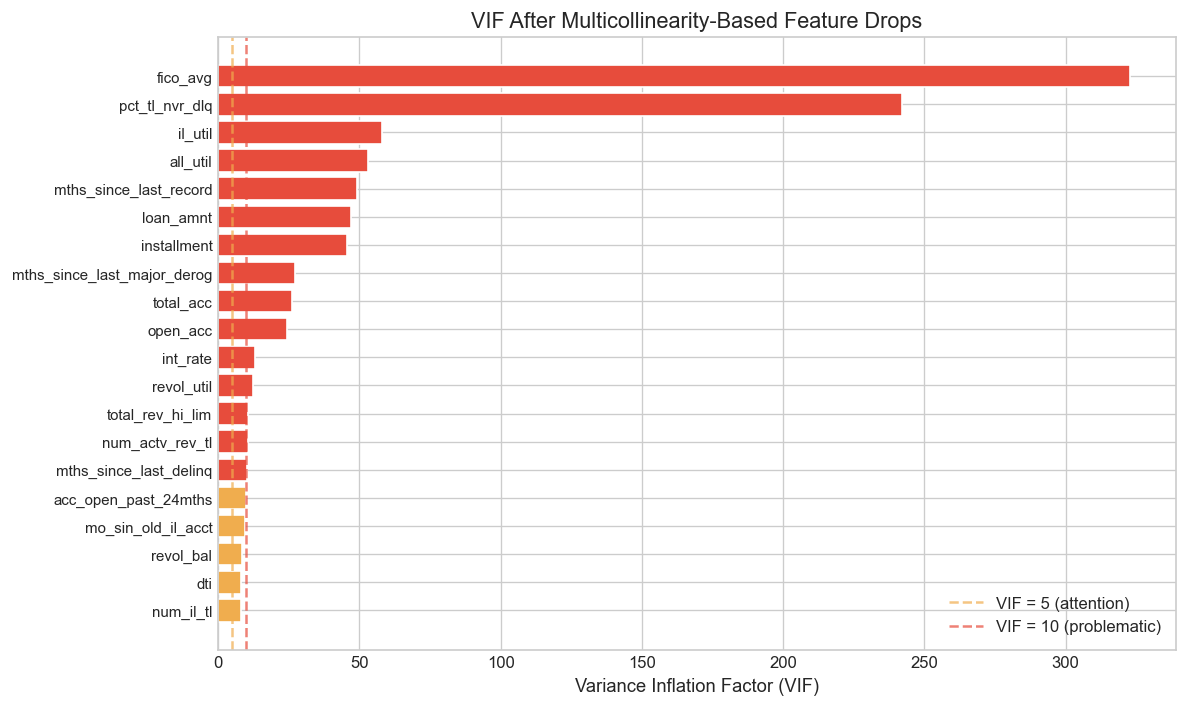

In [29]:
fig, ax = plt.subplots(figsize=(10, 6))

# Color bars by VIF severity
colors = []
for v in vif_data["VIF"]:
    if v > 10:
        colors.append(COLORS["default"])       # Red — problematic
    elif v > 5:
        colors.append("#f0ad4e")               # Amber — warrants attention
    else:
        colors.append(COLORS["non_default"])    # Blue — acceptable

top_vif = vif_data.head(20)
top_colors = colors[:20]
ax.barh(range(len(top_vif)), top_vif["VIF"].values[::-1],
        color=top_colors[::-1], edgecolor="white")
ax.set_yticks(range(len(top_vif)))
ax.set_yticklabels(top_vif["Feature"].values[::-1], fontsize=9)
ax.set_xlabel("Variance Inflation Factor (VIF)")
ax.set_title("VIF After Multicollinearity-Based Feature Drops")
ax.axvline(x=5, color="#f0ad4e", linestyle="--", alpha=0.7, label="VIF = 5 (attention)")
ax.axvline(x=10, color=COLORS["default"], linestyle="--", alpha=0.7, label="VIF = 10 (problematic)")
ax.legend(loc="lower right")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "vif_after_drops.png", dpi=150, bbox_inches="tight")
plt.show()

**VIF validation results**:

After removing the 24 redundant features and excluding temporary date-derived variables, the retained predictor set shows materially reduced multicollinearity, although some features still exhibit elevated VIF values due to structural relationships in credit data. In particular, variables such as `loan_amnt`, `installment`, `fico_avg`, `int_rate`, and utilization measures may remain mechanically or economically related even when they are not true duplicates.

This is most relevant for logistic regression, where multicollinearity affects coefficient stability and interpretability. The VIF results should therefore be treated as a diagnostic input rather than a strict feature-selection rule, and the retained feature set can still be refined further in Notebook 03 if needed.

In [30]:
vif_data

,Feature,VIF
0,fico_avg,322.956545
1,pct_tl_nvr_dlq,241.936162
2,il_util,58.129642
3,all_util,53.047428
4,mths_since_last_record,49.226520
5,loan_amnt,47.171910
6,installment,45.537471
7,mths_since_last_major_derog,27.291172
8,total_acc,26.240196
9,open_acc,24.254684


## 4. Missing Value Patterns in Training Set

Understanding missingness is critical for preprocessing decisions. Notebook 01 flagged substantial structured missingness in several bureau-related variables. Here we examine whether missingness is related to the target (informative missingness).

In [31]:
# Missing value summary for training set
train_missing = df_train.drop(columns=[TARGET_COL, "issue_date", "issue_year", "issue_month",
                                        "issue_year_month", "grade_letter"]).isnull().mean() * 100
train_missing = train_missing[train_missing > 0].sort_values(ascending=False)

print(f"Features with missing values in training set: {len(train_missing)}")
print()

# Check if missingness is related to default
missing_vs_target = []
for col in train_missing.index[:15]:
    missing_mask = df_train[col].isna()
    rate_missing = df_train.loc[missing_mask, TARGET_COL].mean()
    rate_present = df_train.loc[~missing_mask, TARGET_COL].mean()
    missing_vs_target.append({
        "feature": col,
        "missing_pct": train_missing[col],
        "default_rate_when_missing": rate_missing * 100,
        "default_rate_when_present": rate_present * 100,
        "diff_pct_points": (rate_missing - rate_present) * 100,
    })

missing_target_df = pd.DataFrame(missing_vs_target).round(2)
missing_target_df

Features with missing values in training set: 61



,feature,missing_pct,default_rate_when_missing,default_rate_when_present,diff_pct_points
0,mths_since_last_record,82.96,19.34,22.81,-3.47
1,mths_since_recent_bc_dlq,76.07,19.61,20.97,-1.36
2,mths_since_last_major_derog,73.68,19.23,21.89,-2.66
3,il_util,71.47,18.54,23.42,-4.88
4,mths_since_rcnt_il,68.06,18.46,23.06,-4.60
5,all_util,67.23,18.38,23.12,-4.74
6,inq_last_12m,67.23,18.38,23.12,-4.74
7,total_cu_tl,67.23,18.38,23.12,-4.74
8,open_acc_6m,67.23,18.38,23.12,-4.74
9,max_bal_bc,67.23,18.38,23.12,-4.74


> **Insight:**  For several features, the default rate differs meaningfully between rows where the value is missing vs. present. This suggests that missingness is informative rather than random (MNAR - Missing Not At Random). During preprocessing, we should consider creating binary "is_missing" indicator features for these columns rather than simply imputing with the median, as the missingness pattern itself carries predictive signal.

## 5. Default Rate Over Time (Training Set Only)

Examining how the default rate evolves over the training period helps us understand whether the relationship between features and default is stable or shifting.

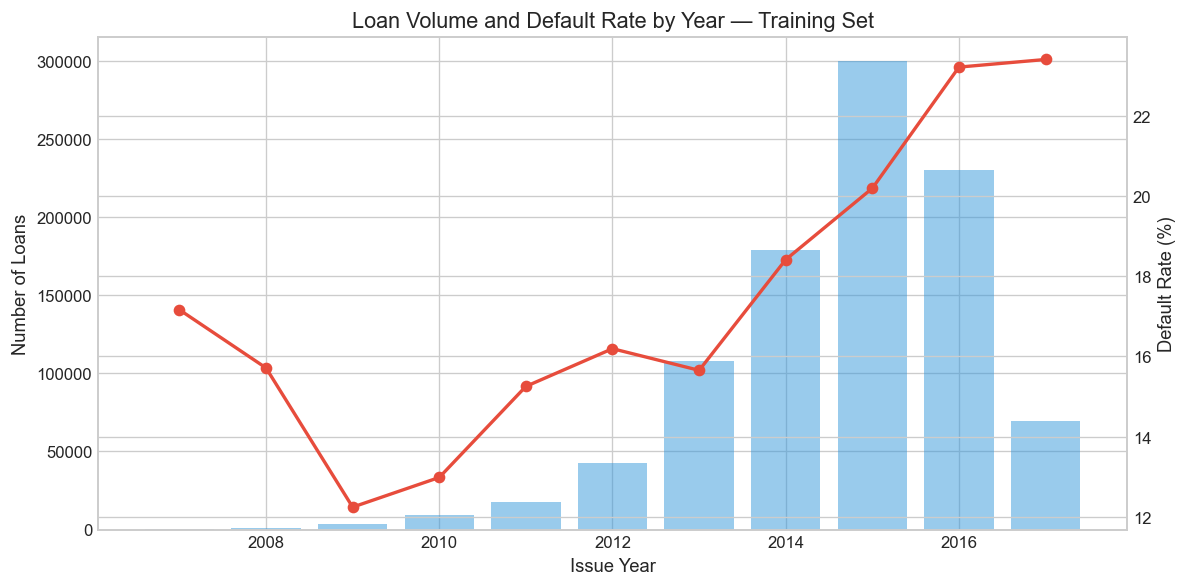

,issue_year,n_loans,default_rate,default_rate_pct
0,2007,204,0.171569,17.16
1,2008,1254,0.157097,15.71
2,2009,3718,0.122378,12.24
3,2010,9234,0.129846,12.98
4,2011,17274,0.152484,15.25
5,2012,42740,0.161862,16.19
6,2013,108010,0.156513,15.65
7,2014,178527,0.184123,18.41
8,2015,300007,0.201895,20.19
9,2016,230300,0.232128,23.21


In [32]:
yearly_stats = (
    df_train.groupby("issue_year")[TARGET_COL]
    .agg(["count", "mean"])
    .rename(columns={"count": "n_loans", "mean": "default_rate"})
    .reset_index()
)
yearly_stats["default_rate_pct"] = (yearly_stats["default_rate"] * 100).round(2)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(yearly_stats["issue_year"], yearly_stats["n_loans"], color=COLORS["secondary"], alpha=0.5)
ax1.set_ylabel("Number of Loans")
ax1.set_xlabel("Issue Year")

ax2 = ax1.twinx()
ax2.plot(yearly_stats["issue_year"], yearly_stats["default_rate_pct"],
         color=COLORS["default"], linewidth=2, marker="o", markersize=6)
ax2.set_ylabel("Default Rate (%)")
ax1.set_title("Loan Volume and Default Rate by Year — Training Set")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "default_rate_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

yearly_stats

> **Insight:** Default rates were highest during the 2007–2008 financial crisis period, declined as underwriting standards tightened, and have been relatively stable in recent years.

## 6. Key EDA Findings and Implications for Modelling

| Finding | Implication |
|---|---|
| Default rate ~20%, 4:1 class imbalance | Use ROC-AUC and precision-recall metrics; consider class weights |
| Sub-grade and interest rate are the strongest univariate predictors | Highly correlated — may need to choose one or use tree-based models that handle collinearity |
| FICO score shows strong monotonic relationship with default | Retain `fico_avg` as a key feature |
| 60-month loans default at ~2x the rate of 36-month loans | `term` is a strong binary predictor |
| DTI and revolving utilization show clear positive association with default | Important credit risk features |
| Employment length is a weak predictor | May still contribute in combination with other features |
| Verification status is counter-intuitive (verified = higher default) | Reflects selection bias — retain as-is |
| Loan purpose provides meaningful risk segmentation | Encode as categorical feature |
| Missingness is informative for several features | Create binary missing indicators during preprocessing |
| Default rate varies over time | Out-of-time split is appropriate; consider vintage effects |

**Next steps for Notebook 03:**
- load the saved `train.csv`, `val.csv`, and `holdout.csv`
- engineer features such as `credit_age_months` using `issue_d` and `earliest_cr_line`
- apply column dropping and categorical cleaning consistently across all three splits
- handle missing values with median imputation and missing indicators where appropriate
- encode categorical variables (`sub_grade`, `home_ownership`, `purpose`, `emp_length`, etc.)
- fit preprocessing pipelines on `df_train` only and apply them to `df_val` and `df_holdout`
- drop helper raw columns such as `issue_d` and `earliest_cr_line` only after feature engineering

## 7. Save Train, Validation, and Holdout Splits

In [33]:
# Save train, validation, and holdout base tables for Notebook 03
# Multicollinearity-based drops are documented here but deferred to Notebook 03

df_train_save = df_train.copy()
df_val_save = df_val.copy()
df_holdout_save = df_holdout.copy()

# Drop temporary EDA-only columns that are not predictors
temp_cols = ["issue_date", "issue_year", "issue_month", "issue_year_month", "grade_letter"]

df_train_save = df_train_save.drop(columns=[c for c in temp_cols if c in df_train_save.columns])
df_val_save = df_val_save.drop(columns=[c for c in temp_cols if c in df_val_save.columns])
df_holdout_save = df_holdout_save.drop(columns=[c for c in temp_cols if c in df_holdout_save.columns])

# Save outputs
df_train_save.to_csv(PROCESSED_DIR / "train.csv", index=False)
df_val_save.to_csv(PROCESSED_DIR / "val.csv", index=False)
df_holdout_save.to_csv(PROCESSED_DIR / "holdout.csv", index=False)

print(f"Train set saved:      {df_train_save.shape[0]:,} rows x {df_train_save.shape[1]:,} columns")
print(f"Validation set saved: {df_val_save.shape[0]:,} rows x {df_val_save.shape[1]:,} columns")
print(f"Holdout set saved:    {df_holdout_save.shape[0]:,} rows x {df_holdout_save.shape[1]:,} columns")
print("Multicollinearity drop list documented for Notebook 03, but not applied here.")
print(f"\nFiles saved to: {PROCESSED_DIR}")

Train set saved:      960,780 rows x 85 columns
Validation set saved: 240,195 rows x 85 columns
Holdout set saved:    69,339 rows x 85 columns
Multicollinearity drop list documented for Notebook 03, but not applied here.

Files saved to: ../data/processed


In [34]:
# Quick sanity check
print("Train set target distribution:")
print(df_train_save[TARGET_COL].value_counts())
print(f"Default rate: {df_train_save[TARGET_COL].mean():.4f}")
print()

print("Validation set target distribution:")
print(df_val_save[TARGET_COL].value_counts())
print(f"Default rate: {df_val_save[TARGET_COL].mean():.4f}")
print()

print("Holdout set target distribution:")
print(df_holdout_save[TARGET_COL].value_counts())
print(f"Default rate: {df_holdout_save[TARGET_COL].mean():.4f}")

Train set target distribution:
target
0    769270
1    191510
Name: count, dtype: int64
Default rate: 0.1993

Validation set target distribution:
target
0    192317
1     47878
Name: count, dtype: int64
Default rate: 0.1993

Holdout set target distribution:
target
0    53948
1    15391
Name: count, dtype: int64
Default rate: 0.2220


**Notebook 02 is complete.** The main outputs are:

1. **Split design:** The retained modelling base table was first split into a **development sample** (2007–Jun 2017) and an **out-of-time holdout** (Jul–Dec 2017). All 2018 loans were excluded due to insufficient maturity.
2. **Train / validation split:** The development sample was further split into **training** and **validation** subsets before any target-conditioned EDA.
3. **EDA findings:** Key risk signals were identified across sub-grade, interest rate, FICO score, DTI, term, home ownership, loan purpose, verification status, and credit behaviour features.
4. **Preprocessing guidance:** Informative missingness patterns, counter-intuitive verification status, and feature correlation structure were documented for Notebook 03.

The notebook outputs `train.csv`, `val.csv`, and `holdout.csv` for downstream feature engineering and preprocessing.